In [ ]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
##  — Dataset Overview

# Load the dataset into a pandas DataFrame named 'df'
# Assuming your dataset is in '/content/seasonal_agriculture_performance_dataset.csv'
# If your file has a different name or path, please update it here.
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print("--- Dataset Shape ---")
print(df.shape)

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Column Names and Data Types ---")
df.info()

print("\n--- Exact Column Names List ---")
print(df.columns.tolist())

--- Dataset Shape ---
(4000, 28)

--- First 5 Rows ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



--- Column Names and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg

In [ ]:
##  — Clean Column Names and Identify Key Columns

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("--- Cleaned Column Names ---")
print(df.columns.tolist())

# --- IMPORTANT: Identify the actual column names from your dataset here ---
# Based on the 'Cleaned Column Names' list printed above, assign your actual column names
# to the conceptual variables below. If a conceptual column is not present in your dataset,
# keep its assignment as None or comment it out.
# This step is critical for the subsequent analysis cells to function correctly.

# Please REPLACE the placeholder assignments below with your actual column names.
# For example, if your dataset has a column named 'Average_Yield', you would set `yield_col = 'Average_Yield'`.
# If a column does not exist in your dataset, keep it as `None`.

# --- User needs to fill these based on their dataset --- START
season_col = 'Season' # Corrected: 'Season' is the actual column name
crop_col = 'Crop' # Corrected: 'Crop' is the actual column name
region_col = 'District' # Corrected: Using 'District' as a representative region column. 'State' could also be used.
yield_col = 'Yield_Tonnes_Ha' # Corrected: 'Yield_Tonnes_Ha' is the actual column name
production_col = 'Production_Tonnes' # Corrected: 'Production_Tonnes' is the actual column name
rainfall_col = 'Rainfall_mm' # Corrected: 'Rainfall_mm' is the actual column name
temperature_col = 'Avg_Temperature_C' # Corrected: 'Avg_Temperature_C' is the actual column name
fertilizer_col = 'Fertilizer_kg_ha' # Corrected: 'Fertilizer_kg_ha' is the actual column name
pesticide_col = 'Pesticide_Litre_ha' # Corrected: 'Pesticide_Litre_ha' is the actual column name
cost_col = 'Total_Cost_INR' # Corrected: 'Total_Cost_INR' is the actual column name
price_col = 'Market_Price_INR_Tonne' # Corrected: 'Market_Price_INR_Tonne' is the actual column name
profit_col = 'Profit_INR' # Corrected: 'Profit_INR' is the actual column name
# --- User needs to fill these based on their dataset --- END


# Storing identified columns in a dictionary for easy access and verification
identified_cols = {
    'Season': season_col,
    'Crop': crop_col,
    'Region': region_col,
    'Yield': yield_col,
    'Production': production_col,
    'Rainfall': rainfall_col,
    'Temperature': temperature_col,
    'Fertilizer': fertilizer_col,
    'Pesticide': pesticide_col,
    'Cost': cost_col,
    'Price': price_col,
    'Profit': profit_col
}

print("\n--- Identified Conceptual Columns (Verify these are correct) ---")
for key, value in identified_cols.items():
    if value and value in df.columns:
        print(f"{key}: {value} (Found)")
    elif value:
        print(f"{key}: {value} (Warning: Column '{value}' not found in dataset! Please correct in CELL 4.)")
    else:
        print(f"{key}: Not Assigned (Column not identified or not available)")


--- Cleaned Column Names ---
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

--- Identified Conceptual Columns (Verify these are correct) ---
Season: Season (Found)
Crop: Crop (Found)
Region: District (Found)
Yield: Yield_Tonnes_Ha (Found)
Production: Production_Tonnes (Found)
Rainfall: Rainfall_mm (Found)
Temperature: Avg_Temperature_C (Found)
Fertilizer: Fertilizer_kg_ha (Found)
Pesticide: Pesticide_Litre_ha (Found)
Cost: Total_Cost_INR (Found)
Price: Market_Price_INR_Tonne (Found)
Profit: Profit_INR (Found)


In [ ]:
##  — Data Quality Check

print("--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Check ---")
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

print("\n--- Basic Data Types (before detailed cleaning) ---")
df.info()


--- Missing Values Check ---
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0

In [ ]:
##  — Data Cleaning

print("--- Dataset Shape Before Cleaning ---")
print(df.shape)

# 1. Remove duplicate rows if any
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
removed_duplicates = initial_rows - df.shape[0]
print(f"Removed {removed_duplicates} duplicate rows.")

# --- Start: Robust handling for identified categorical columns (Season, Crop, Region) ---
print("\n--- Processing identified categorical columns ('Season', 'Crop', 'District') ---")
identified_categorical_cols = [identified_cols['Season'], identified_cols['Crop'], identified_cols['Region']]
for col_name in identified_categorical_cols:
    if col_name and col_name in df.columns:
        # Ensure it's string type first
        df[col_name] = df[col_name].astype(str)
        # Clean string inconsistencies
        df[col_name] = df[col_name].str.strip().str.title()
        # Fill NaNs that might have been created by astype(str) from actual NaNs, or existing 'nan' strings
        # Convert explicit 'Nan' string back to actual NaN for proper fillna.
        df[col_name] = df[col_name].replace({'Nan': np.nan, 'None': np.nan}) # Replace string 'Nan' or 'None' to actual NaN
        if df[col_name].isnull().any():
            mode_series = df[col_name].mode()
            if not mode_series.empty:
                mode_val = mode_series[0]
                df[col_name].fillna(mode_val, inplace=True)
                print(f"Filled missing values in identified categorical column '{col_name}' with mode ('{mode_val}').")
            else:
                df[col_name].fillna('Unknown', inplace=True)
                print(f"Filled missing values in identified categorical column '{col_name}' with 'Unknown' (no mode found).")
        print(f"Ensured '{col_name}' is string type and cleaned. Current dtype: {df[col_name].dtype}")
    else:
        print(f"Identified categorical column '{col_name}' not found. Skipping.")
# --- End: Robust handling for identified categorical columns ---

# 2. Handle missing values for OTHER numeric columns
print("\n--- Filling NaNs in other numeric columns (excluding identified categorical ones) ---")
numeric_cols_for_fillna = [col for col in df.select_dtypes(include=np.number).columns.tolist() if col not in identified_categorical_cols]
for col in numeric_cols_for_fillna:
    if col and col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in numeric column '{col}' with median ({median_val}).")

# 3. Handle missing values for OTHER categorical columns
print("\n--- Filling NaNs in other categorical columns (excluding identified ones) ---")
# This now focuses on other object columns that are not 'Season', 'Crop', 'Region'
other_categorical_cols_for_fillna = [col for col in df.select_dtypes(include='object').columns.tolist() if col not in identified_categorical_cols]
for col in other_categorical_cols_for_fillna:
    if col and col in df.columns and df[col].isnull().any():
        mode_series = df[col].mode()
        if not mode_series.empty:
            mode_val = mode_series[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Filled missing values in categorical column '{col}' with mode ('{mode_val}').")
        else:
            df[col].fillna('Unknown', inplace=True)
            print(f"Filled missing values in categorical column '{col}' with 'Unknown' (no mode found).")

# 4. Convert identified numeric columns to numeric where necessary
print("\n--- Converting identified numeric columns to numeric type ---")
numeric_identified_cols = [
    identified_cols['Yield'], identified_cols['Production'], identified_cols['Rainfall'],
    identified_cols['Temperature'], identified_cols['Fertilizer'], identified_cols['Pesticide'],
    identified_cols['Cost'], identified_cols['Price'], identified_cols['Profit']
]
for col_name in numeric_identified_cols:
    if col_name and col_name in df.columns:
        original_dtype = df[col_name].dtype
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
        if original_dtype != df[col_name].dtype:
            print(f"Converted '{col_name}' from {original_dtype} to {df[col_name].dtype}.")
        if df[col_name].isnull().any():
            median_val = df[col_name].median()
            df[col_name].fillna(median_val, inplace=True)
            print(f"Filled any new NaNs in '{col_name}' with median ({median_val}).")


print("\n--- Dataset Shape After Cleaning ---")
print(df.shape)

print("\n--- Missing Values Check After Cleaning ---")
print(df.isnull().sum())
print("\n--- Dtypes After Cleaning ---")
print(df.dtypes)

--- Dataset Shape Before Cleaning ---
(4000, 28)
Removed 0 duplicate rows.

--- Processing identified categorical columns ('Season', 'Crop', 'District') ---
Ensured 'Season' is string type and cleaned. Current dtype: object
Ensured 'Crop' is string type and cleaned. Current dtype: object
Ensured 'District' is string type and cleaned. Current dtype: object

--- Filling NaNs in other numeric columns (excluding identified categorical ones) ---
Filled missing values in numeric column 'Rainfall_mm' with median (582.0).
Filled missing values in numeric column 'Soil_Moisture_pct' with median (26.4).
Filled missing values in numeric column 'Yield_Tonnes_Ha' with median (1.74).

--- Filling NaNs in other categorical columns (excluding identified ones) ---

--- Converting identified numeric columns to numeric type ---

--- Dataset Shape After Cleaning ---
(4000, 28)

--- Missing Values Check After Cleaning ---
Farm_ID                          0
State                            0
District        

/tmp/ipykernel_3848/3525060354.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [ ]:
##  — Descriptive Statistics

print("--- Descriptive Statistics for Numeric Columns ---")
display(df.describe())

# Explanation of statistics:
print("\n--- Interpretation ---")
print("The descriptive statistics provide a summary of the central tendency, dispersion, and shape of the distribution of numeric columns.")
print("- `count`: Number of non-null observations, indicating data completeness.")
print("- `mean`: Average value, representing the central point.")
print("- `std`: Standard deviation, measuring the spread or variability of the data.")
print("- `min` and `max`: Smallest and largest values, showing the range of data.")
print("- `25%`, `50%` (median), `75%`: Quartiles, indicating the distribution of data points. The median (50%) is particularly useful as it is less affected by outliers than the mean.")
print("These statistics help in understanding the basic properties of each numeric variable, identifying potential outliers, or checking for skewed distributions.")

--- Descriptive Statistics for Numeric Columns ---


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000



--- Interpretation ---
The descriptive statistics provide a summary of the central tendency, dispersion, and shape of the distribution of numeric columns.
- `count`: Number of non-null observations, indicating data completeness.
- `mean`: Average value, representing the central point.
- `std`: Standard deviation, measuring the spread or variability of the data.
- `min` and `max`: Smallest and largest values, showing the range of data.
- `25%`, `50%` (median), `75%`: Quartiles, indicating the distribution of data points. The median (50%) is particularly useful as it is less affected by outliers than the mean.
These statistics help in understanding the basic properties of each numeric variable, identifying potential outliers, or checking for skewed distributions.


In [ ]:
###  — Seasonal Analysis
print("--- Seasonal Analysis ---")

if season_col in df.columns:

    print(f"Using season column: {season_col}")

    # Create seasonal summary
    seasonal_summary = df.groupby(season_col).size().reset_index(name="Number of Records")

    # Add average metrics if available
    if yield_col and yield_col in df.columns:
        yield_avg = df.groupby(season_col)[yield_col].mean().reset_index(name="Average Yield")
        seasonal_summary = seasonal_summary.merge(yield_avg, on=season_col)

    if production_col and production_col in df.columns:
        production_avg = df.groupby(season_col)[production_col].mean().reset_index(name="Average Production")
        seasonal_summary = seasonal_summary.merge(production_avg, on=season_col)

    if rainfall_col and rainfall_col in df.columns:
        rainfall_avg = df.groupby(season_col)[rainfall_col].mean().reset_index(name="Average Rainfall")
        seasonal_summary = seasonal_summary.merge(rainfall_avg, on=season_col)

    if temperature_col and temperature_col in df.columns:
        temperature_avg = df.groupby(season_col)[temperature_col].mean().reset_index(name="Average Temperature")
        seasonal_summary = seasonal_summary.merge(temperature_avg, on=season_col)

    if fertilizer_col and fertilizer_col in df.columns:
        fertilizer_avg = df.groupby(season_col)[fertilizer_col].mean().reset_index(name="Average Fertilizer")
        seasonal_summary = seasonal_summary.merge(fertilizer_avg, on=season_col)

    if pesticide_col and pesticide_col in df.columns:
        pesticide_avg = df.groupby(season_col)[pesticide_col].mean().reset_index(name="Average Pesticide")
        seasonal_summary = seasonal_summary.merge(pesticide_avg, on=season_col)

    if cost_col and cost_col in df.columns:
        cost_avg = df.groupby(season_col)[cost_col].mean().reset_index(name="Average Cost")
        seasonal_summary = seasonal_summary.merge(cost_avg, on=season_col)

    if price_col and price_col in df.columns:
        price_avg = df.groupby(season_col)[price_col].mean().reset_index(name="Average Price")
        seasonal_summary = seasonal_summary.merge(price_avg, on=season_col)

    if profit_col and profit_col in df.columns:
        profit_avg = df.groupby(season_col)[profit_col].mean().reset_index(name="Average Profit")
        seasonal_summary = seasonal_summary.merge(profit_avg, on=season_col)

    # Display result
    display(seasonal_summary)

else:
    print("Season column not found.")


--- Seasonal Analysis ---
Using season column: Season


,Season,Number of Records,Average Yield,Average Production,Average Rainfall,Average Temperature,Average Fertilizer,Average Pesticide,Average Cost,Average Price,Average Profit
0,Kharif,1779,5.628612,46.311192,849.199663,28.454019,187.077965,5.079747,531804.408094,44850.906127,178914.647555
1,Rabi,1627,5.039435,41.486712,437.615366,23.489183,185.407068,5.024690,513836.578365,44747.974800,87689.470191
2,Zaid,594,4.641313,38.886111,304.654714,31.042088,184.638047,5.171212,543976.728956,44212.033670,-24804.824916


--- Seasonal Visualizations ---


/tmp/ipykernel_3848/3779580603.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=season_col, data=df, palette='viridis')


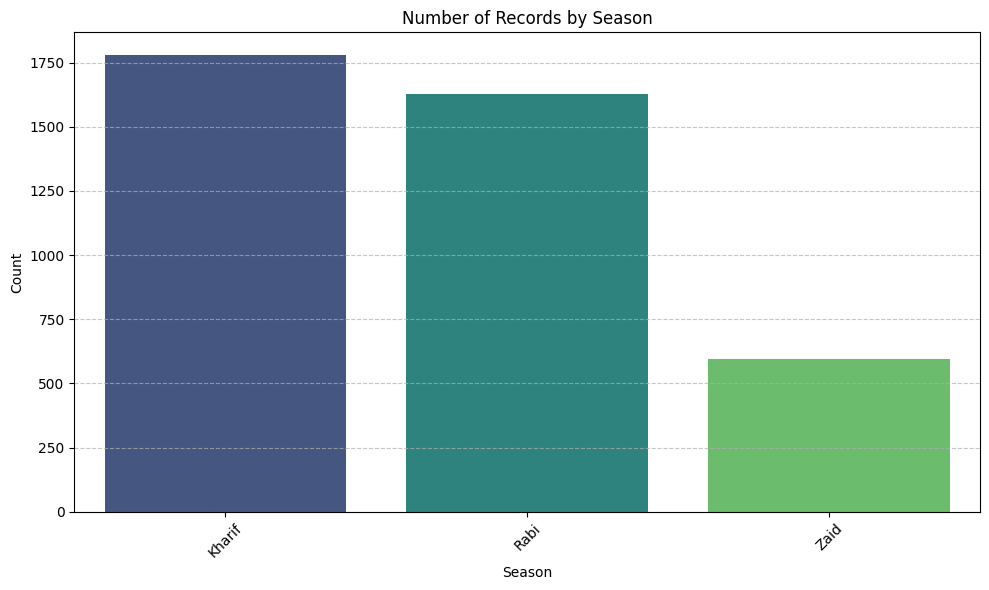

/tmp/ipykernel_3848/3779580603.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_col, y=yield_col, data=df, estimator=np.mean, palette='plasma')


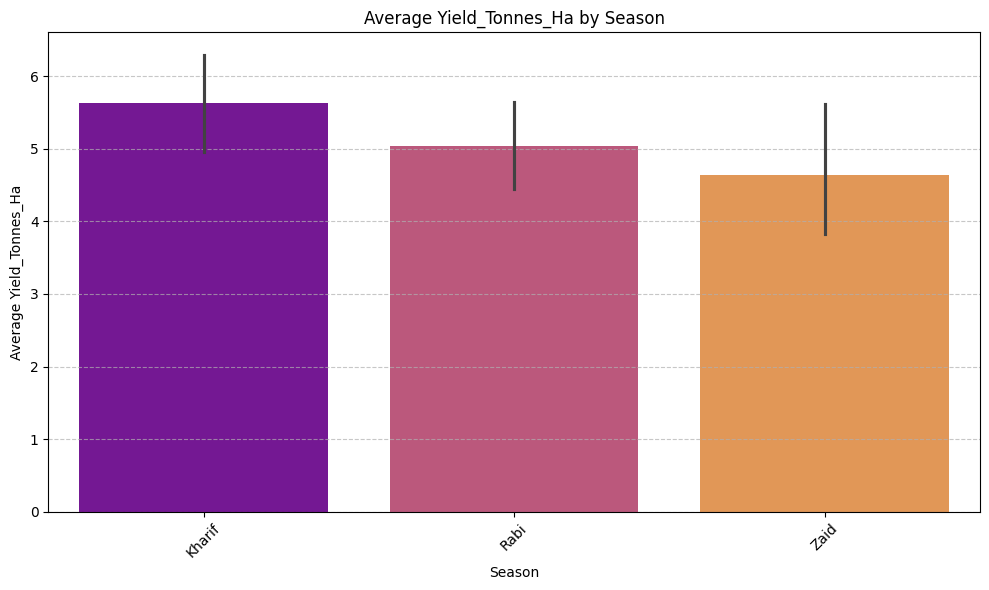

/tmp/ipykernel_3848/3779580603.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_col, y=production_col, data=df, estimator=np.mean, palette='mako')


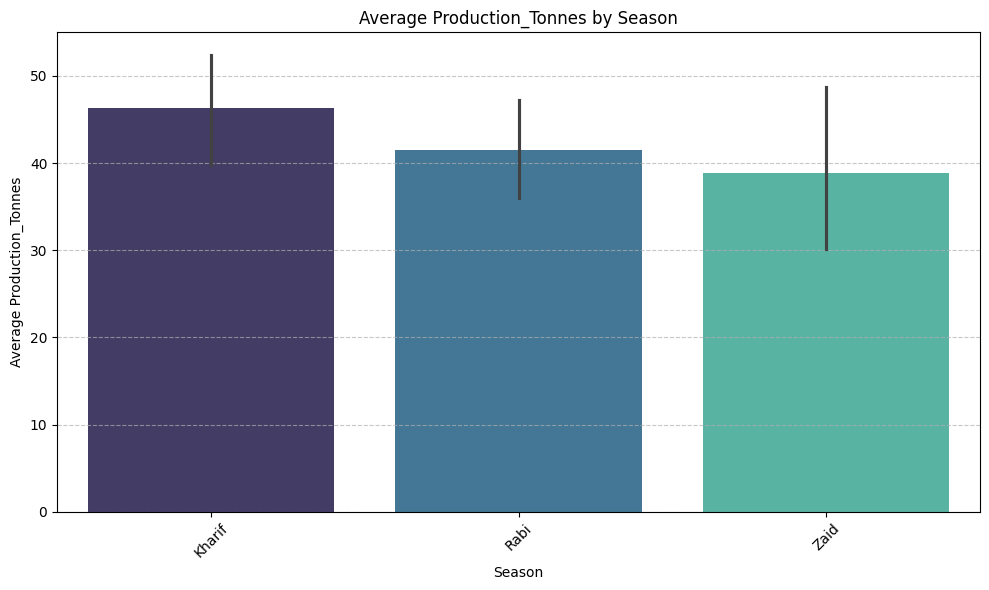

In [ ]:
##  — Seasonal Visualization

print("--- Seasonal Visualizations ---")

if season_col and season_col in df.columns:
    # 1. Season-wise record count
    plt.figure(figsize=(10, 6))
    sns.countplot(x=season_col, data=df, palette='viridis')
    plt.title(f'Number of Records by {season_col}')
    plt.xlabel(season_col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 2. Average Yield by Season (if yield_col exists)
    if yield_col and yield_col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=season_col, y=yield_col, data=df, estimator=np.mean, palette='plasma')
        plt.title(f'Average {yield_col} by {season_col}')
        plt.xlabel(season_col)
        plt.ylabel(f'Average {yield_col}')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: '{yield_col}' column not found or not assigned. Skipping Average Yield by Season chart.")

    # 3. Average Production by Season (if production_col exists)
    if production_col and production_col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=season_col, y=production_col, data=df, estimator=np.mean, palette='mako')
        plt.title(f'Average {production_col} by {season_col}')
        plt.xlabel(season_col)
        plt.ylabel(f'Average {production_col}')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: '{production_col}' column not found or not assigned. Skipping Average Production by Season chart.")

else:
    print(f"Seasonal column '{season_col}' not found or not assigned. Skipping seasonal visualizations.")

--- Crop Analysis ---
Performing analysis based on the identified crop column: 'Crop'

Total number of unique crops: 8

--- Crop Frequency ---


,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



--- Average Yield_Tonnes_Ha by Crop (Top 10) ---


,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


/tmp/ipykernel_3848/2670243253.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_yield_by_crop.head(10).index, y=avg_yield_by_crop.head(10).values, palette='Greens_r')


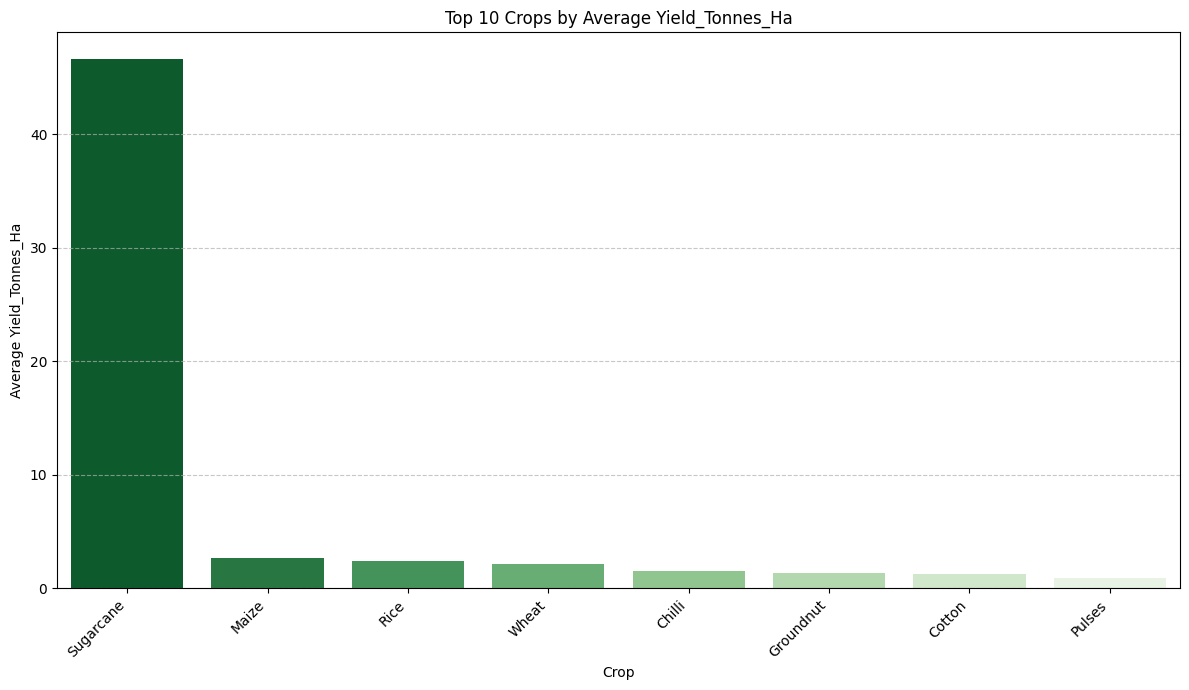


--- Average Production_Tonnes by Crop (Top 10) ---


,Production_Tonnes
Crop,
Sugarcane,392.413016
Maize,21.781125
Rice,19.288623
Wheat,16.853909
Chilli,12.382888
Groundnut,9.655825
Cotton,9.395866
Pulses,7.401411


/tmp/ipykernel_3848/2670243253.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_production_by_crop.head(10).index, y=avg_production_by_crop.head(10).values, palette='Blues_r')


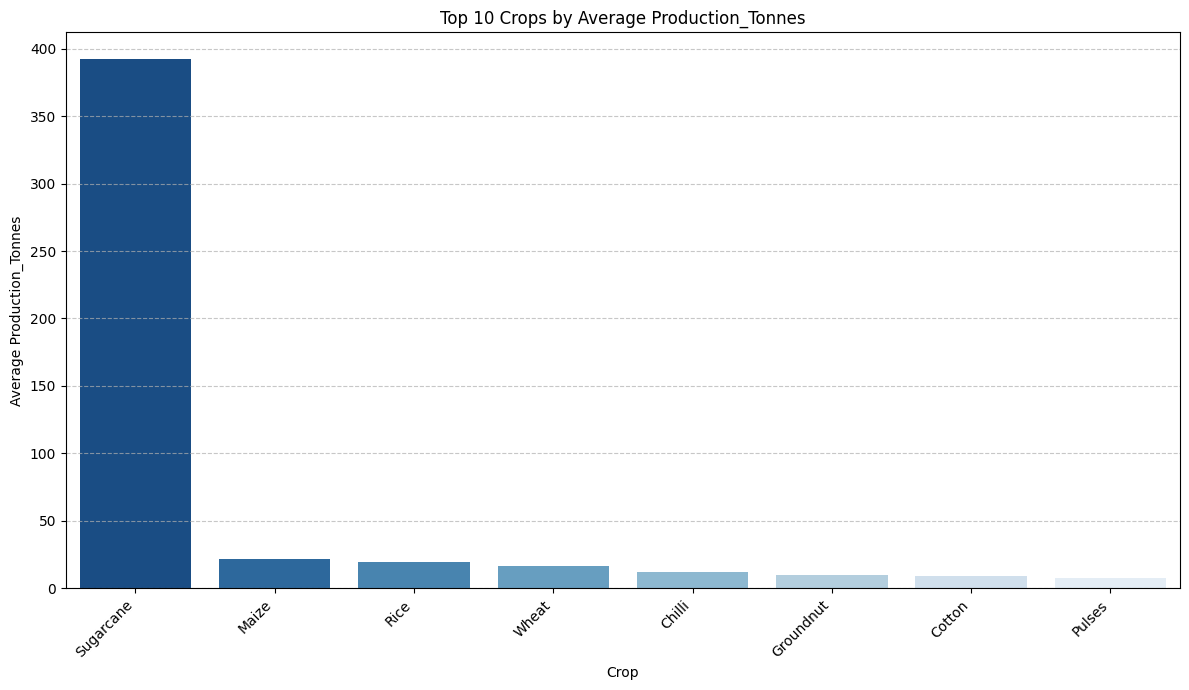

In [ ]:
##  — Crop Analysis

print("--- Crop Analysis ---")

if crop_col and crop_col in df.columns:
    print(f"Performing analysis based on the identified crop column: '{crop_col}'")

    # Number of unique crops
    num_crops = df[crop_col].nunique()
    print(f"\nTotal number of unique crops: {num_crops}")

    # Crop frequency
    print("\n--- Crop Frequency ---")
    display(df[crop_col].value_counts().head(10))

    # Average Yield by Crop (if yield_col exists)
    if yield_col and yield_col in df.columns:
        print(f"\n--- Average {yield_col} by {crop_col} (Top 10) ---")
        avg_yield_by_crop = df.groupby(crop_col)[yield_col].mean().sort_values(ascending=False)
        display(avg_yield_by_crop.head(10))

        plt.figure(figsize=(12, 7))
        sns.barplot(x=avg_yield_by_crop.head(10).index, y=avg_yield_by_crop.head(10).values, palette='Greens_r')
        plt.title(f'Top 10 Crops by Average {yield_col}')
        plt.xlabel(crop_col)
        plt.ylabel(f'Average {yield_col}')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    else:
        print(f"Warning: '{yield_col}' column not found or not assigned. Cannot analyze average yield by crop.")

    # Average Production by Crop (if production_col exists)
    if production_col and production_col in df.columns:
        print(f"\n--- Average {production_col} by {crop_col} (Top 10) ---")
        avg_production_by_crop = df.groupby(crop_col)[production_col].mean().sort_values(ascending=False)
        display(avg_production_by_crop.head(10))

        plt.figure(figsize=(12, 7))
        sns.barplot(x=avg_production_by_crop.head(10).index, y=avg_production_by_crop.head(10).values, palette='Blues_r')
        plt.title(f'Top 10 Crops by Average {production_col}')
        plt.xlabel(crop_col)
        plt.ylabel(f'Average {production_col}')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: '{production_col}' column not found or not assigned. Cannot analyze average production by crop.")

else:
    print(f"Crop column '{crop_col}' not found or not assigned. Skipping crop analysis.")

--- Crop by Season Comparison ---
Comparing Yield_Tonnes_Ha across Crop and Season.

--- Average Yield_Tonnes_Ha by Crop and Season ---


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588



--- Important Differences ---
In Kharif, 'Sugarcane' tends to have the highest average Yield_Tonnes_Ha (53.46).
In Rabi, 'Sugarcane' tends to have the highest average Yield_Tonnes_Ha (43.29).
In Zaid, 'Sugarcane' tends to have the highest average Yield_Tonnes_Ha (38.42).


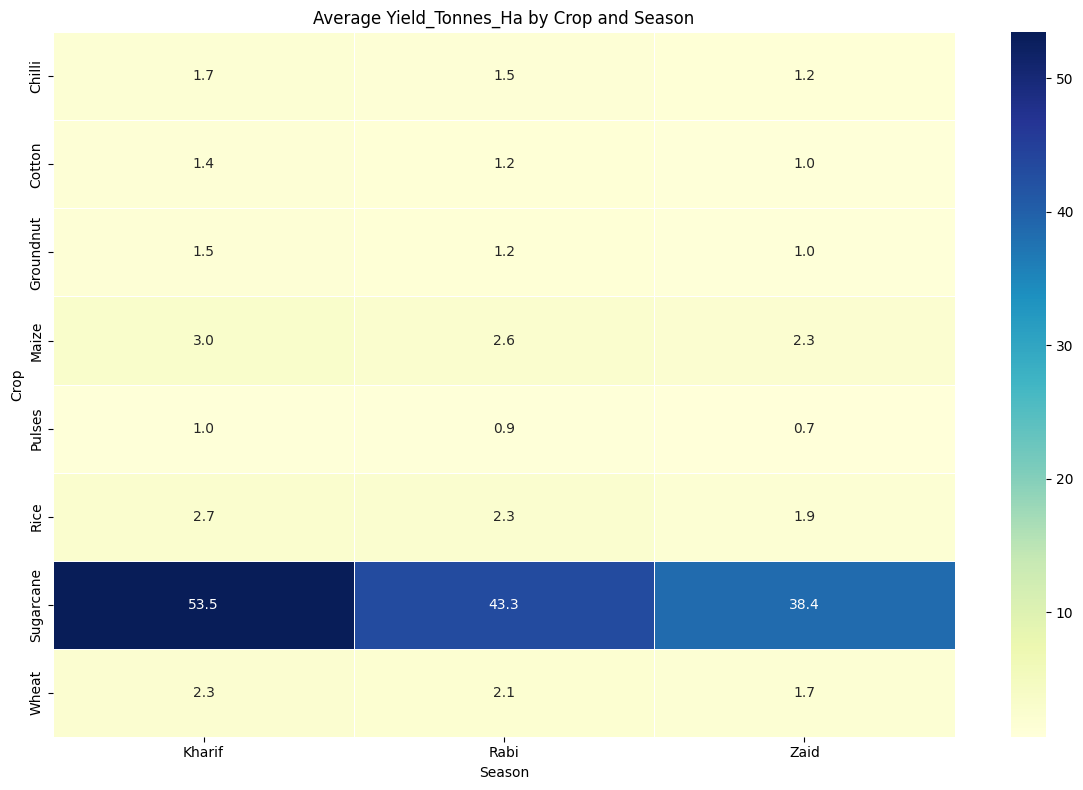

In [ ]:
## — Crop × Season Comparison

print("--- Crop by Season Comparison ---")

if crop_col and crop_col in df.columns and season_col and season_col in df.columns and yield_col and yield_col in df.columns:
    print(f"Comparing {yield_col} across {crop_col} and {season_col}.")

    # Create a pivot table for Average Yield by Crop and Season
    crop_season_yield_pivot = pd.pivot_table(df, values=yield_col, index=crop_col, columns=season_col, aggfunc='mean')
    print(f"\n--- Average {yield_col} by {crop_col} and {season_col} ---")
    display(crop_season_yield_pivot.head(10)) # Displaying head for brevity

    print("\n--- Important Differences ---")
    # Identify crops that perform significantly better in specific seasons
    # For a simple beginner level, we can just look for max values per season or per crop
    for season in crop_season_yield_pivot.columns:
        best_crop_in_season = crop_season_yield_pivot[season].idxmax()
        max_yield_in_season = crop_season_yield_pivot[season].max()
        print(f"In {season}, '{best_crop_in_season}' tends to have the highest average {yield_col} ({max_yield_in_season:.2f}).")

    # You can also visualize this with a heatmap if there are not too many crops/seasons
    if crop_season_yield_pivot.shape[0] < 20 and crop_season_yield_pivot.shape[1] < 10: # Limit for readability
        plt.figure(figsize=(12, 8))
        sns.heatmap(crop_season_yield_pivot, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
        plt.title(f'Average {yield_col} by {crop_col} and {season_col}')
        plt.xlabel(season_col)
        plt.ylabel(crop_col)
        plt.tight_layout()
        plt.show()
    else:
        print("\nToo many crops or seasons to display a heatmap effectively. Displaying pivot table only.")

else:
    missing_cols = []
    if not crop_col or crop_col not in df.columns: missing_cols.append('Crop')
    if not season_col or season_col not in df.columns: missing_cols.append('Season')
    if not yield_col or yield_col not in df.columns: missing_cols.append('Yield')
    print(f"Required columns for Crop x Season comparison missing or not assigned: {', '.join(missing_cols)}. Skipping analysis.")

--- Region/Category Comparison ---
Comparing agricultural performance (Yield_Tonnes_Ha) across District and Season.

--- Average Yield_Tonnes_Ha by District and Season ---


Season,Kharif,Rabi,Zaid
District,,,
Erode,4.312011,4.427338,3.285714
Guntur,6.024056,4.542941,6.224912
Indore,6.120820,3.535779,4.538364
Krishna,5.507760,4.717610,2.883922
Ludhiana,6.379412,5.536684,5.075821
Nalgonda,6.582151,4.437458,7.423182
Nashik,5.530359,4.695862,3.390339
Raichur,4.079775,6.669320,3.287705
Rajkot,6.656242,5.963889,4.326786



--- Regional Performance Differences ---

Region: Erode
  Kharif - Average Yield_Tonnes_Ha: 4.31
  Rabi - Average Yield_Tonnes_Ha: 4.43
  Zaid - Average Yield_Tonnes_Ha: 3.29

Region: Guntur
  Kharif - Average Yield_Tonnes_Ha: 6.02
  Rabi - Average Yield_Tonnes_Ha: 4.54
  Zaid - Average Yield_Tonnes_Ha: 6.22

Region: Indore
  Kharif - Average Yield_Tonnes_Ha: 6.12
  Rabi - Average Yield_Tonnes_Ha: 3.54
  Zaid - Average Yield_Tonnes_Ha: 4.54

Region: Krishna
  Kharif - Average Yield_Tonnes_Ha: 5.51
  Rabi - Average Yield_Tonnes_Ha: 4.72
  Zaid - Average Yield_Tonnes_Ha: 2.88

Region: Ludhiana
  Kharif - Average Yield_Tonnes_Ha: 6.38
  Rabi - Average Yield_Tonnes_Ha: 5.54
  Zaid - Average Yield_Tonnes_Ha: 5.08

Region: Nalgonda
  Kharif - Average Yield_Tonnes_Ha: 6.58
  Rabi - Average Yield_Tonnes_Ha: 4.44
  Zaid - Average Yield_Tonnes_Ha: 7.42

Region: Nashik
  Kharif - Average Yield_Tonnes_Ha: 5.53
  Rabi - Average Yield_Tonnes_Ha: 4.70
  Zaid - Average Yield_Tonnes_Ha: 3.39

Region: 

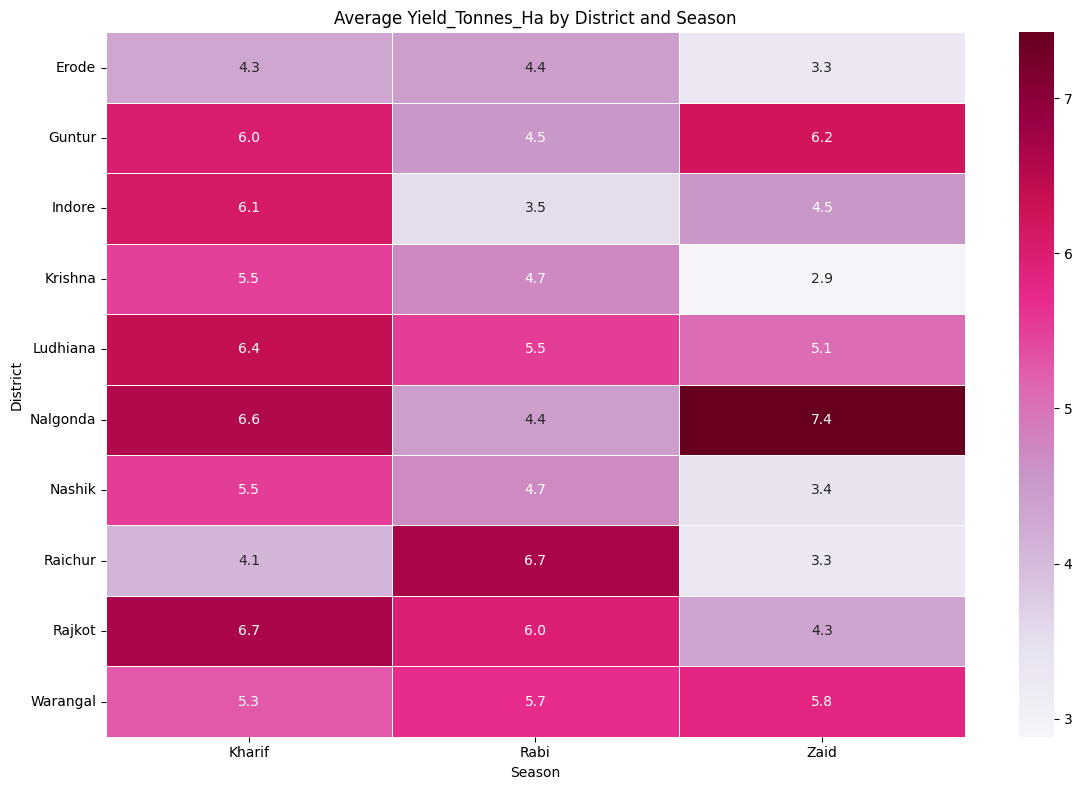

In [ ]:
##  — Region/Category Comparison

print("--- Region/Category Comparison ---")

if region_col and region_col in df.columns and season_col and season_col in df.columns and yield_col and yield_col in df.columns:
    print(f"Comparing agricultural performance ({yield_col}) across {region_col} and {season_col}.")

    # Create a pivot table for Average Yield by Region and Season
    region_season_yield_pivot = pd.pivot_table(df, values=yield_col, index=region_col, columns=season_col, aggfunc='mean')
    print(f"\n--- Average {yield_col} by {region_col} and {season_col} ---")
    display(region_season_yield_pivot.head(10)) # Displaying head for brevity

    print("\n--- Regional Performance Differences ---")
    for region in region_season_yield_pivot.index:
        print(f"\nRegion: {region}")
        for season in region_season_yield_pivot.columns:
            yield_val = region_season_yield_pivot.loc[region, season]
            if pd.notna(yield_val):
                print(f"  {season} - Average {yield_col}: {yield_val:.2f}")
            else:
                print(f"  {season} - Average {yield_col}: N/A")

    # You can also visualize this with a heatmap
    if region_season_yield_pivot.shape[0] < 20 and region_season_yield_pivot.shape[1] < 10: # Limit for readability
        plt.figure(figsize=(12, 8))
        sns.heatmap(region_season_yield_pivot, annot=True, fmt=".1f", cmap="PuRd", linewidths=.5)
        plt.title(f'Average {yield_col} by {region_col} and {season_col}')
        plt.xlabel(season_col)
        plt.ylabel(region_col)
        plt.tight_layout()
        plt.show()
    else:
        print("\nToo many regions or seasons to display a heatmap effectively. Displaying pivot table only.")

elif not region_col or region_col not in df.columns:
    print(f"Region/category column '{region_col}' not available or not assigned — analysis skipped.")
else:
    missing_cols = []
    if not season_col or season_col not in df.columns: missing_cols.append('Season')
    if not yield_col or yield_col not in df.columns: missing_cols.append('Yield')
    print(f"Required columns for Region x Season comparison missing or not assigned: {', '.join(missing_cols)}. Skipping analysis.")

--- Environmental and Resource Relationships ---

--- Relationship: Rainfall vs Yield ---


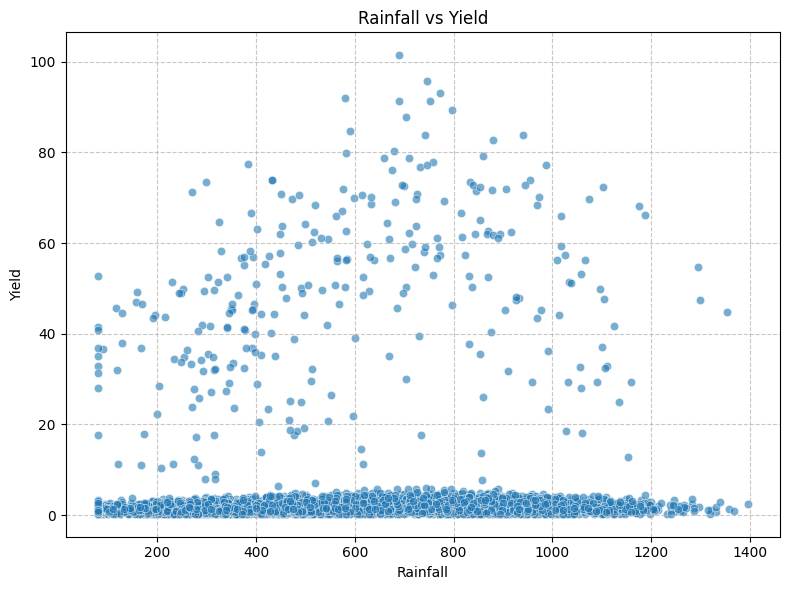

Correlation between Rainfall and Yield: 0.03
There appears to be a weak or no linear relationship.
Remember: Correlation does not prove causation.

--- Relationship: Temperature vs Yield ---


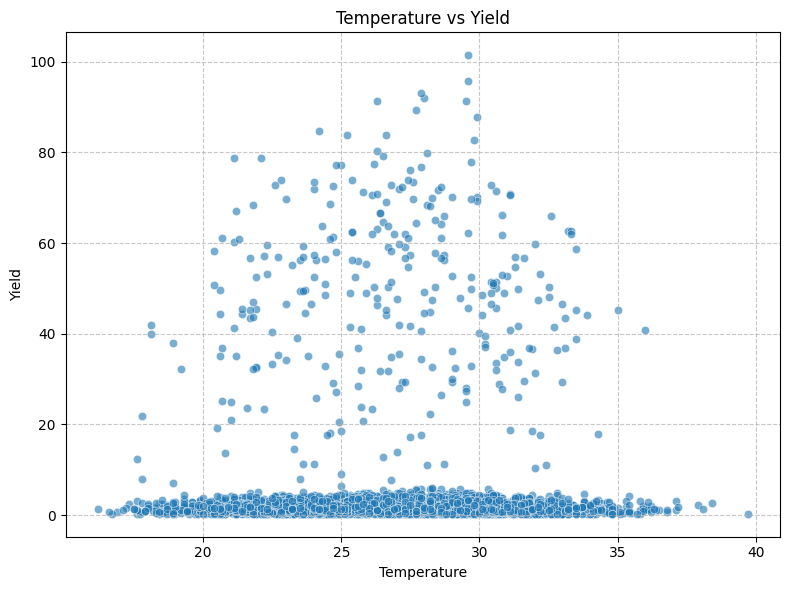

Correlation between Temperature and Yield: 0.01
There appears to be a weak or no linear relationship.
Remember: Correlation does not prove causation.

--- Relationship: Fertilizer Usage vs Yield ---


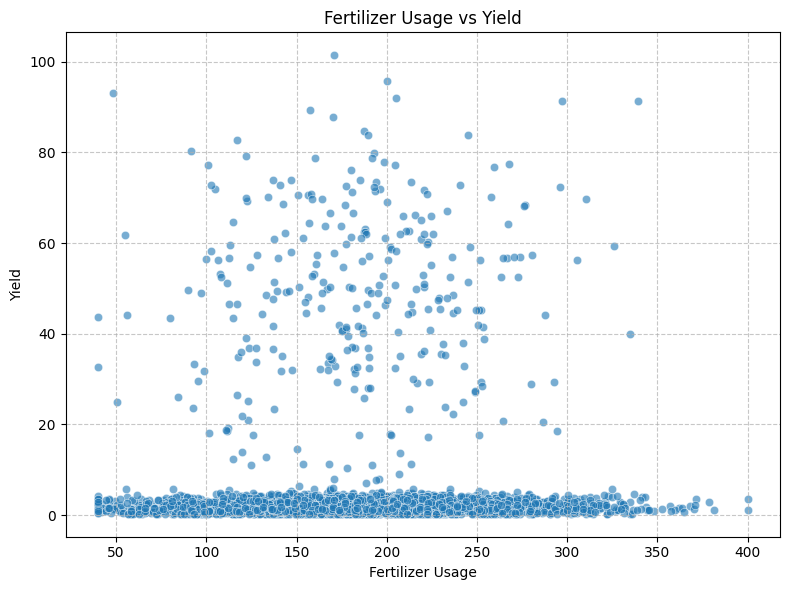

Correlation between Fertilizer Usage and Yield: 0.00
There appears to be a weak or no linear relationship.
Remember: Correlation does not prove causation.

--- Relationship: Pesticide Usage vs Yield ---


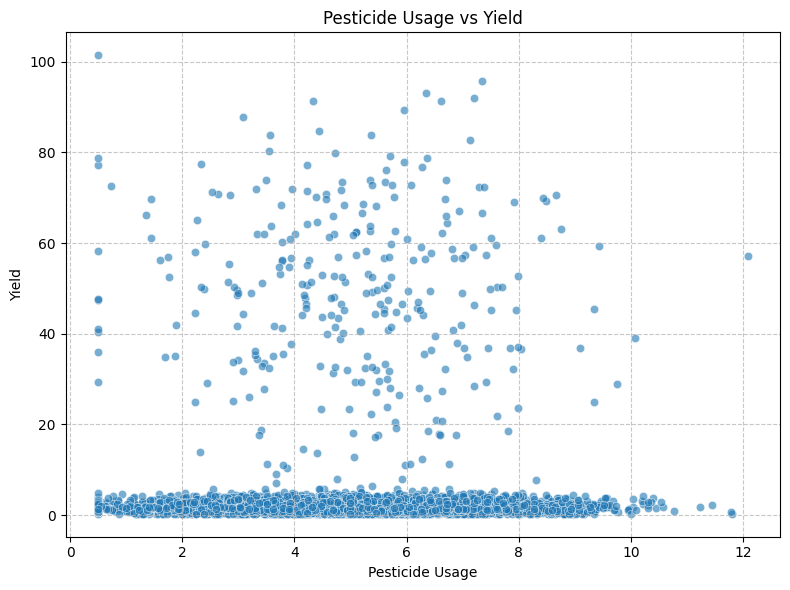

Correlation between Pesticide Usage and Yield: -0.01
There appears to be a weak or no linear relationship.
Remember: Correlation does not prove causation.


In [ ]:
##  — Environmental and Resource Relationships

print("--- Environmental and Resource Relationships ---")

# List of potential independent variables and a dependent variable
independent_vars = [
    (rainfall_col, 'Rainfall'),
    (temperature_col, 'Temperature'),
    (fertilizer_col, 'Fertilizer Usage'),
    (pesticide_col, 'Pesticide Usage'),
]
dependent_var = (yield_col, 'Yield')

if dependent_var[0] and dependent_var[0] in df.columns:
    for iv_col, iv_label in independent_vars:
        if iv_col and iv_col in df.columns:
            print(f"\n--- Relationship: {iv_label} vs {dependent_var[1]} ---")
            plt.figure(figsize=(8, 6))
            sns.scatterplot(x=iv_col, y=dependent_var[0], data=df, alpha=0.6)
            plt.title(f'{iv_label} vs {dependent_var[1]}')
            plt.xlabel(iv_label)
            plt.ylabel(dependent_var[1])
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

            # Simple textual explanation
            correlation = df[[iv_col, dependent_var[0]]].corr().iloc[0, 1]
            print(f"Correlation between {iv_label} and {dependent_var[1]}: {correlation:.2f}")
            if correlation > 0.5: explanation = "There appears to be a strong positive relationship."
            elif correlation < -0.5: explanation = "There appears to be a strong negative relationship."
            elif 0.2 < correlation <= 0.5: explanation = "There appears to be a moderate positive relationship."
            elif -0.5 <= correlation < -0.2: explanation = "There appears to be a moderate negative relationship."
            elif -0.2 <= correlation <= 0.2: explanation = "There appears to be a weak or no linear relationship."
            else: explanation = "Further investigation may be needed to understand this relationship."
            print(explanation)

            print("Remember: Correlation does not prove causation.")

        else:
            print(f"Warning: Independent variable column '{iv_col}' not found or not assigned. Skipping relationship analysis for {iv_label}.")
else:
    print(f"Dependent variable column '{yield_col}' (Yield) not found or not assigned. Skipping environmental and resource relationship analysis.")

--- Correlation Matrix for Numeric Columns ---


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


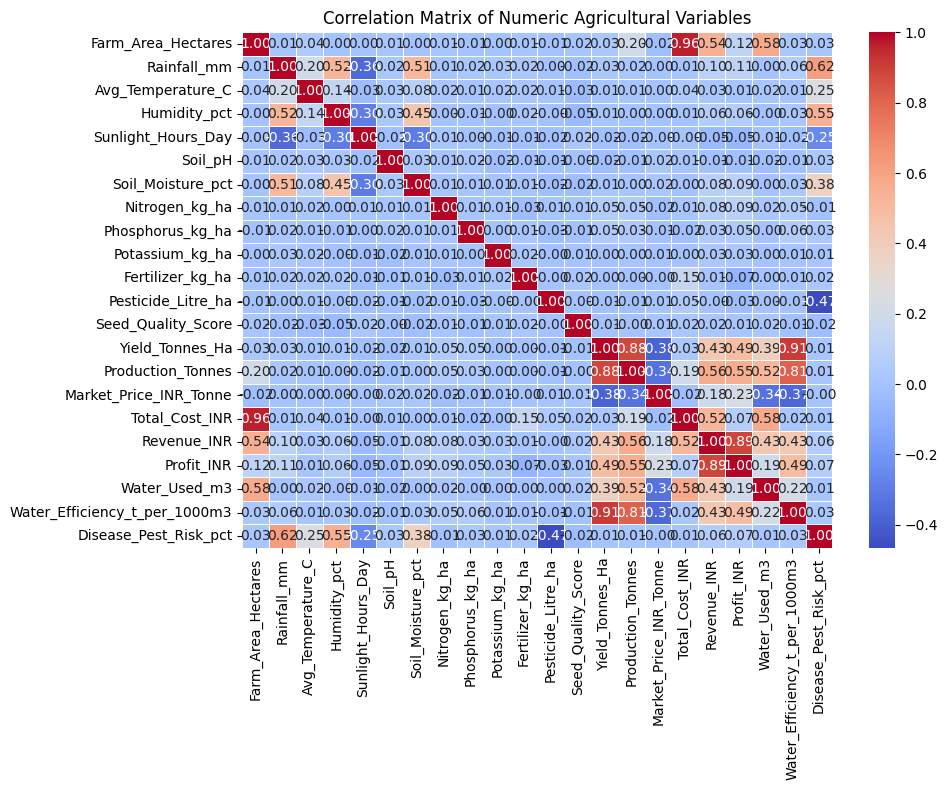


--- Statistical Comparison (ANOVA if applicable) ---
Imported scipy.stats for ANOVA.

--- ANOVA Test: Variation in Yield Across Seasons ---
Test Name: One-way ANOVA
F-statistic: 1.54
p-value: 0.214

--- Simple Interpretation ---
With a p-value (0.214) greater than the significance level (0.05), we fail to reject the null hypothesis.
This suggests there is no statistically significant difference in average Yield_Tonnes_Ha across seasons based on this test.


In [ ]:
## CELL 15 — Correlation + Statistical Comparison

print("--- Correlation Matrix for Numeric Columns ---")
# Create a simple correlation matrix for all numeric columns
numeric_df = df.select_dtypes(include=np.number)
if not numeric_df.empty:
    correlation_matrix = numeric_df.corr()
    display(correlation_matrix)

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
    plt.title('Correlation Matrix of Numeric Agricultural Variables')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found for correlation matrix.")

print("\n--- Statistical Comparison (ANOVA if applicable) ---")

if season_col and season_col in df.columns and yield_col and yield_col in df.columns:
    # Check if there are at least two seasons to compare
    unique_seasons = df[season_col].nunique()
    if unique_seasons >= 2:
        # Check if SciPy is needed and import it
        try:
            from scipy.stats import f_oneway
            print("Imported scipy.stats for ANOVA.")

            # Prepare data for ANOVA: separate yield values by season
            season_groups = [df[df[season_col] == season][yield_col].dropna() for season in df[season_col].unique()]

            # Ensure there's data in each group for ANOVA
            if all(len(group) > 1 for group in season_groups):
                f_statistic, p_value = f_oneway(*season_groups)
                print("\n--- ANOVA Test: Variation in Yield Across Seasons ---")
                print(f"Test Name: One-way ANOVA")
                print(f"F-statistic: {f_statistic:.2f}")
                print(f"p-value: {p_value:.3f}")

                print("\n--- Simple Interpretation ---")
                alpha = 0.05 # Significance level
                if p_value < alpha:
                    print(f"With a p-value ({p_value:.3f}) less than the significance level ({alpha}), we reject the null hypothesis.")
                    print(f"This suggests there are statistically significant differences in average {yield_col} between at least some of the seasons.")
                else:
                    print(f"With a p-value ({p_value:.3f}) greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
                    print(f"This suggests there is no statistically significant difference in average {yield_col} across seasons based on this test.")
            else:
                print("Not enough data points in some season groups for ANOVA. Skipping ANOVA.")

        except ImportError:
            print("Scipy not found. Skipping ANOVA test.")
        except Exception as e:
            print(f"Could not perform ANOVA: {e}")
    else:
        print("Fewer than two unique seasons found. ANOVA requires at least two groups to compare. Skipping ANOVA.")
else:
    print(f"Required columns for ANOVA ('{season_col}' or '{yield_col}') not found or not assigned. Skipping statistical comparison.")

In [ ]:
##  — Unusual Patterns / Significant Observations

print("--- Unusual Patterns / Significant Observations ---")

# 1. Very high/low yield (if yield_col exists)
if yield_col and yield_col in df.columns:
    mean_yield = df[yield_col].mean()
    std_yield = df[yield_col].std()
    # Define outliers as values beyond 2 standard deviations (simple approach)
    high_yield_threshold = mean_yield + (2 * std_yield)
    low_yield_threshold = mean_yield - (2 * std_yield)

    unusually_high_yield = df[df[yield_col] > high_yield_threshold].sort_values(by=yield_col, ascending=False)
    unusually_low_yield = df[df[yield_col] < low_yield_threshold].sort_values(by=yield_col, ascending=True)

    if not unusually_high_yield.empty:
        print(f"\n--- Instances of Unusually High {yield_col} (Above {high_yield_threshold:.2f}) ---")
        display(unusually_high_yield.head())
    else:
        print(f"\nNo unusually high {yield_col} observations (above {high_yield_threshold:.2f}) found.")

    if not unusually_low_yield.empty:
        print(f"\n--- Instances of Unusually Low {yield_col} (Below {low_yield_threshold:.2f}) ---")
        display(unusually_low_yield.head())
    else:
        print(f"\nNo unusually low {yield_col} observations (below {low_yield_threshold:.2f}) found.")

else:
    print(f"Warning: '{yield_col}' column not found or not assigned. Skipping unusual yield analysis.")

# 2. Large seasonal differences (from Cell 9 summary)
if 'seasonal_summary' in locals() and season_col and yield_col and f'Average {yield_col}' in seasonal_summary.columns:
    max_avg_yield_season = seasonal_summary.loc[seasonal_summary[f'Average {yield_col}'].idxmax(), season_col]
    min_avg_yield_season = seasonal_summary.loc[seasonal_summary[f'Average {yield_col}'].idxmin(), season_col]
    max_yield_val = seasonal_summary[f'Average {yield_col}'].max()
    min_yield_val = seasonal_summary[f'Average {yield_col}'].min()

    print(f"\n--- Significant Seasonal Differences in {yield_col} ---")
    print(f"Season with highest average {yield_col}: '{max_avg_yield_season}' ({max_yield_val:.2f})")
    print(f"Season with lowest average {yield_col}: '{min_avg_yield_season}' ({min_yield_val:.2f})")
    print(f"The difference between highest and lowest average {yield_col} is substantial, indicating clear seasonal impact.")
else:
    print("Cannot assess large seasonal differences due to missing seasonal summary or yield column.")

# 3. Unusual rainfall (if rainfall_col exists)
if rainfall_col and rainfall_col in df.columns:
    mean_rainfall = df[rainfall_col].mean()
    std_rainfall = df[rainfall_col].std()
    high_rainfall_threshold = mean_rainfall + (2 * std_rainfall)

    unusually_high_rainfall = df[df[rainfall_col] > high_rainfall_threshold].sort_values(by=rainfall_col, ascending=False)
    if not unusually_high_rainfall.empty:
        print(f"\n--- Instances of Unusually High {rainfall_col} (Above {high_rainfall_threshold:.2f}) ---")
        display(unusually_high_rainfall.head())
    else:
        print(f"\nNo unusually high {rainfall_col} observations (above {high_rainfall_threshold:.2f}) found.")
else:
    print(f"Warning: '{rainfall_col}' column not found or not assigned. Skipping unusual rainfall analysis.")

--- Unusual Patterns / Significant Observations ---

--- Instances of Unusually High Yield_Tonnes_Ha (Above 31.87) ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,6.32,689.0,29.6,68.2,5.9,...,0.75,101.44,641.10,3077,364374,1972665,1608291,11781,54.418,60.1
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,745.9,29.6,74.1,6.4,...,0.82,95.79,1424.40,3109,1097878,4428460,3330582,23289,61.162,42.7
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,772.5,27.9,64.5,7.2,...,0.73,93.13,648.18,2917,419212,1890741,1471529,10705,60.549,59.9
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,7.65,579.6,28.0,75.0,5.5,...,1.00,91.98,703.65,3839,484604,2701312,2216708,12787,55.029,44.5
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,0.82,752.4,29.5,67.5,5.8,...,0.85,91.46,75.00,3898,58030,292350,234320,1944,38.580,54.4



No unusually low Yield_Tonnes_Ha observations (below -21.38) found.
Cannot assess large seasonal differences due to missing seasonal summary or yield column.

--- Instances of Unusually High Rainfall_mm (Above 1175.31) ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
1495,SF11496,Telangana,Guntur,Wheat,Kharif,3.86,1395.2,25.9,64.4,6.2,...,0.87,2.40,9.26,22646,231318,209702,-21616,3065,3.021,68.2
2887,SF12888,Karnataka,Raichur,Chilli,Kharif,3.46,1367.2,29.1,83.6,5.3,...,0.80,0.83,2.87,115645,224158,331901,107743,1143,2.511,71.9
2247,SF12248,Karnataka,Rajkot,Wheat,Kharif,12.22,1356.9,33.7,82.5,5.8,...,0.89,1.26,15.40,22754,1057159,350412,-706747,8040,1.915,78.3
791,SF10792,Tamil Nadu,Erode,Sugarcane,Kharif,13.49,1353.1,28.2,63.7,8.2,...,0.82,44.78,604.08,3909,1039127,2361349,1322222,13870,43.553,63.5
2435,SF12436,Tamil Nadu,Indore,Maize,Kharif,14.15,1338.9,32.8,80.8,6.8,...,0.91,3.01,42.59,22048,975259,939024,-36235,6997,6.087,65.0
